Premières lignes :
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  are

C:\Users\ndev\AppData\Local\Temp\ipykernel_14796\2979884218.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="diagnosis", palette="magma")


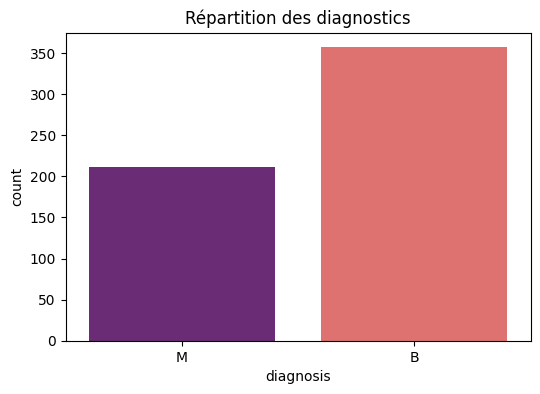


Nombre de valeurs uniques dans diagnosis :
2

Valeurs présentes :
<ArrowStringArray>
['M', 'B']
Length: 2, dtype: str

Après encodage :
0    1
1    1
2    1
3    1
4    1
Name: diagnosis, dtype: int64

Taille Train : (455, 30)
Taille Test : (114, 30)

Précision Régression Logistique : 97.37 %
Précision KNN : 94.74 %
Précision Random Forest : 96.49 %
Précision SVM : 97.37 %

Résultats :
                  Modèle  Précision
0  Régression Logistique   0.973684
1                    KNN   0.947368
2          Random Forest   0.964912
3                    SVM   0.973684

Meilleur modèle :
Modèle       Régression Logistique
Précision                 0.973684
Name: 0, dtype: object


In [2]:
# ==========================================
# 1. IMPORTATION DES LIBRAIRIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score


# ==========================================
# 2. CHARGEMENT DES DONNEES
# ==========================================

df = pd.read_csv("data.csv")

# Afficher les premières lignes
print("Premières lignes :")
print(df.head())


# ==========================================
# 3. VERIFICATION DES VALEURS MANQUANTES
# ==========================================

print("\nValeurs manquantes :")
print(df.isnull().sum())

# Suppression des colonnes inutiles
df.drop(columns=["id", "Unnamed: 32"], inplace=True)

print("\nDimensions après suppression :")
print(df.shape)


# ==========================================
# 4. GRAPHIQUE DE COMPTAGE DU DIAGNOSTIC
# ==========================================

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="diagnosis", palette="magma")
plt.title("Répartition des diagnostics")
plt.show()


# ==========================================
# 5. NOMBRE DE VALEURS UNIQUES
# ==========================================

print("\nNombre de valeurs uniques dans diagnosis :")
print(df["diagnosis"].nunique())

print("\nValeurs présentes :")
print(df["diagnosis"].unique())


# ==========================================
# 6. CONVERSION DES VALEURS CATEGORIELLES
# ==========================================

encoder = LabelEncoder()

df["diagnosis"] = encoder.fit_transform(df["diagnosis"])

# B = 0 , M = 1
print("\nAprès encodage :")
print(df["diagnosis"].head())


# ==========================================
# 7. SEPARATION VARIABLES / CIBLE
# ==========================================

X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]


# ==========================================
# 8. NORMALISATION
# ==========================================

scaler = StandardScaler()

X = scaler.fit_transform(X)


# ==========================================
# 9. DIVISION TRAIN / TEST
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTaille Train :", X_train.shape)
print("Taille Test :", X_test.shape)


# ==========================================
# 10. REGRESSION LOGISTIQUE
# ==========================================

lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)

print("\nPrécision Régression Logistique :",
      round(acc_lr*100,2), "%")


# ==========================================
# 11. K PLUS PROCHES VOISINS (KNN)
# ==========================================

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

acc_knn = accuracy_score(y_test, y_pred_knn)

print("Précision KNN :",
      round(acc_knn*100,2), "%")


# ==========================================
# 12. FORET ALEATOIRE
# ==========================================

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)

print("Précision Random Forest :",
      round(acc_rf*100,2), "%")


# ==========================================
# 13. SVM
# ==========================================

svm = SVC()

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

acc_svm = accuracy_score(y_test, y_pred_svm)

print("Précision SVM :",
      round(acc_svm*100,2), "%")


# ==========================================
# 14. COMPARAISON DES MODELES
# ==========================================

resultats = pd.DataFrame({
    "Modèle": [
        "Régression Logistique",
        "KNN",
        "Random Forest",
        "SVM"
    ],
    "Précision": [
        acc_lr,
        acc_knn,
        acc_rf,
        acc_svm
    ]
})

print("\nRésultats :")
print(resultats)

meilleur_modele = resultats.loc[
    resultats["Précision"].idxmax()
]

print("\nMeilleur modèle :")
print(meilleur_modele)